In [1]:
from google.colab import files
uploaded = files.upload()

Saving decision_tree_large_dataset.csv to decision_tree_large_dataset.csv


In [2]:
import pandas as pd
df=pd.read_csv("decision_tree_large_dataset.csv")

In [3]:
print(df.head(5))

   Hours_Studied  Attendance  Sleep_Hours  Previous_Score  Assignment_Score  \
0             10          71            7              60                65   
1              5          68            6              97                63   
2              9          72            8              44                43   
3             10          66            8             100                35   
4              7          73            9              67                63   

  Pass  
0  Yes  
1  Yes  
2  Yes  
3  Yes  
4  Yes  


In [4]:
df.describe

<bound method NDFrame.describe of      Hours_Studied  Attendance  Sleep_Hours  Previous_Score  Assignment_Score  \
0               10          71            7              60                65   
1                5          68            6              97                63   
2                9          72            8              44                43   
3               10          66            8             100                35   
4                7          73            9              67                63   
..             ...         ...          ...             ...               ...   
195              3          70            7              80                88   
196              6          52            9              49                61   
197              5          61            4              60                77   
198              6          95            4              71                30   
199              7          57            8              59                57   

    Pass  
0    Yes  
1    Yes  
2    Yes  
3    Yes  
4    Yes  
..   ...  
195  Yes  
196  Yes  
197  Yes  
198  Yes  
199  Yes  

[200 rows x 6 columns]>

In [5]:
df.shape

(200, 6)

In [8]:
df["Pass"].value_counts()

,count
Pass,
Yes,183
No,17


In [7]:
print(df.isnull().sum())
df.drop_duplicates()

Hours_Studied       0
Attendance          0
Sleep_Hours         0
Previous_Score      0
Assignment_Score    0
Pass                0
dtype: int64


,Hours_Studied,Attendance,Sleep_Hours,Previous_Score,Assignment_Score,Pass
0,10,71,7,60,65,Yes
1,5,68,6,97,63,Yes
2,9,72,8,44,43,Yes
3,10,66,8,100,35,Yes
4,7,73,9,67,63,Yes
...,...,...,...,...,...,...
195,3,70,7,80,88,Yes
196,6,52,9,49,61,Yes
197,5,61,4,60,77,Yes
198,6,95,4,71,30,Yes


In [9]:
features = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Score",
    "Assignment_Score"
]

def gini(y):
    counts = y.value_counts()
    probabilities = counts / len(y)
    return 1 - (probabilities ** 2).sum()

In [10]:
gini(df["Pass"])

np.float64(0.15554999999999986)

In [11]:
left = df[df["Hours_Studied"] <= 5.5]
right = df[df["Hours_Studied"] > 5.5]

print("Left:", len(left))
print(left["Pass"].value_counts())

print("\nRight:", len(right))
print(right["Pass"].value_counts())

Left: 97
Pass
Yes    80
No     17
Name: count, dtype: int64

Right: 103
Pass
Yes    103
Name: count, dtype: int64


In [12]:
left_gini = gini(left["Pass"])
right_gini = gini(right["Pass"])

print("Left Gini:", left_gini)
print("Right Gini:", right_gini)

Left Gini: 0.28908491869486674
Right Gini: 0.0


In [13]:
weighted_gini = (
    (len(left) / len(df)) * left_gini
    + (len(right) / len(df)) * right_gini
)

print("Weighted Gini:", weighted_gini)

Weighted Gini: 0.14020618556701037


In [14]:
gain = gini(df["Pass"]) - weighted_gini

print("Gini Gain:", gain)

Gini Gain: 0.015343814432989489


In [15]:
X = df.drop("Pass", axis=1)
y = df["Pass"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [18]:
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

Accuracy: 0.925
Accuracy percentage: 92.5 %


In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 2  1]
 [ 2 35]]


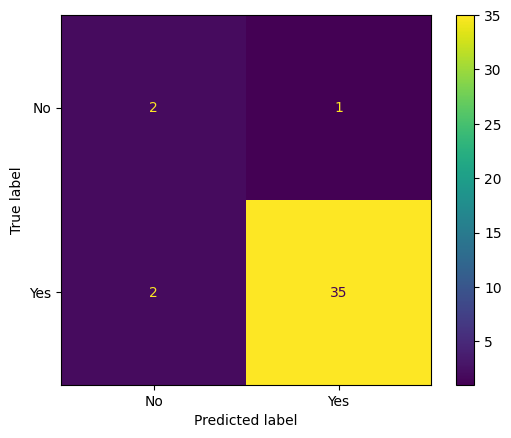

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

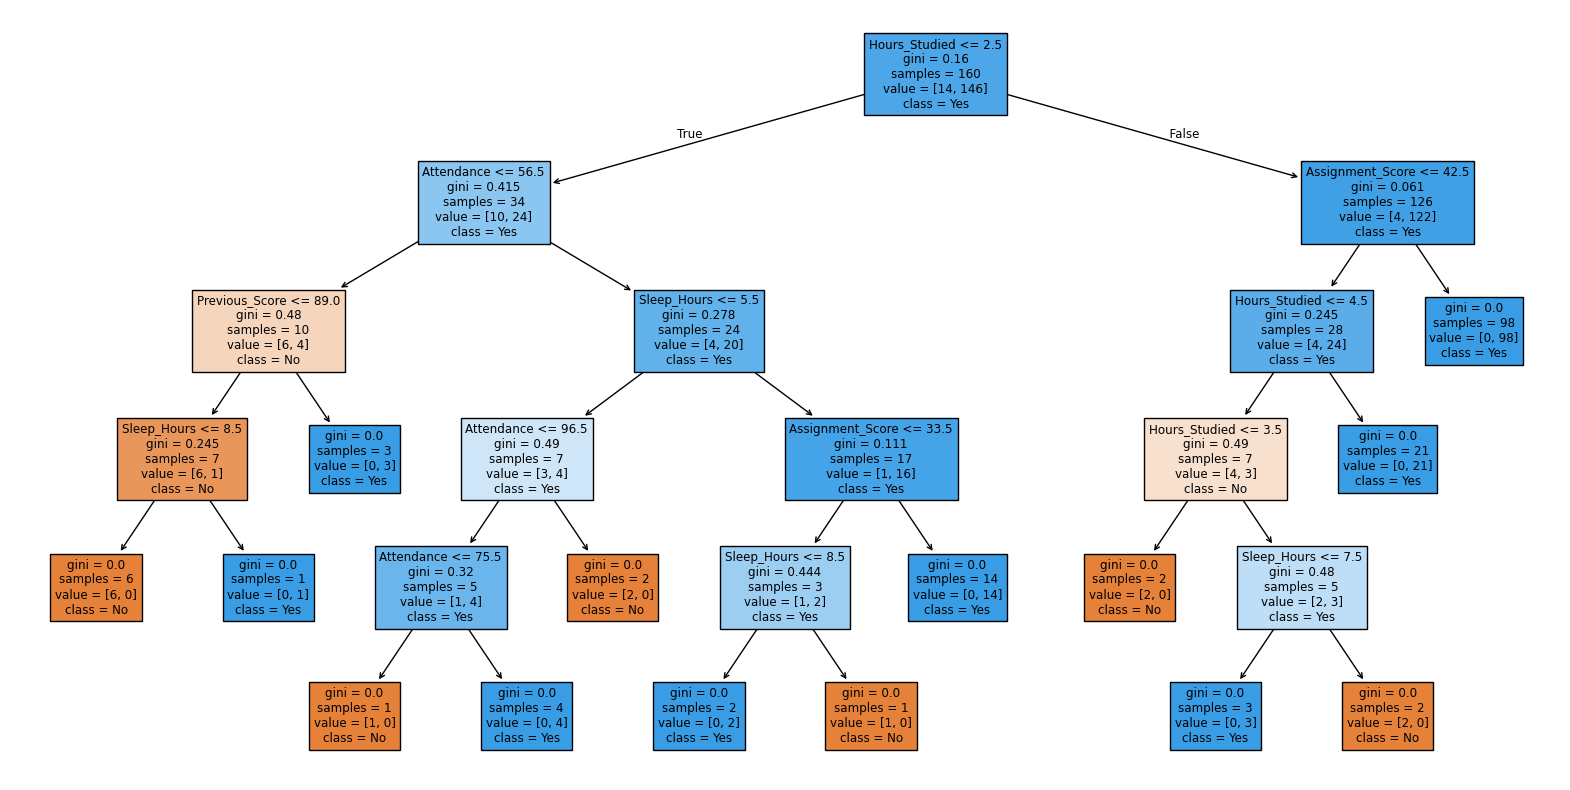

In [22]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True
)

plt.show()